# **Homework 3: Frequency Domain Filtering**

**GROUP 7:**

*   Eren Bal (220611040)
*   Yusuf Seha Güney (230611011)
*   Barkın Gümüş (220611004)


## **Libraries**

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# **Step 1: Create a synthetic gray-scale image with geometric shapes**


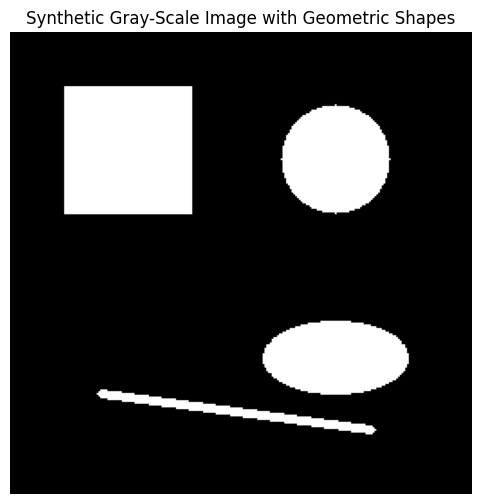

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a blank 256x256 image
image = np.zeros((256, 256), dtype=np.uint8)

# Draw a white rectangle
cv2.rectangle(image, (30, 30), (100, 100), 255, -1)

# Draw a white circle
cv2.circle(image, (180, 70), 30, 255, -1)

# Draw a white line
cv2.line(image, (50, 200), (200, 220), 255, 3)

# Draw a white ellipse
cv2.ellipse(image, (180, 180), (40, 20), 0, 0, 360, 255, -1)

# Display the synthetic image
plt.figure(figsize=(6,6))
plt.title("Synthetic Gray-Scale Image with Geometric Shapes")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

**Explanation:** A synthetic image of 256x256 pixels is created with multiple geometric shapes including a rectangle, circle, line, and ellipse.


# **Step 2: Obtain the spectrum of this image**

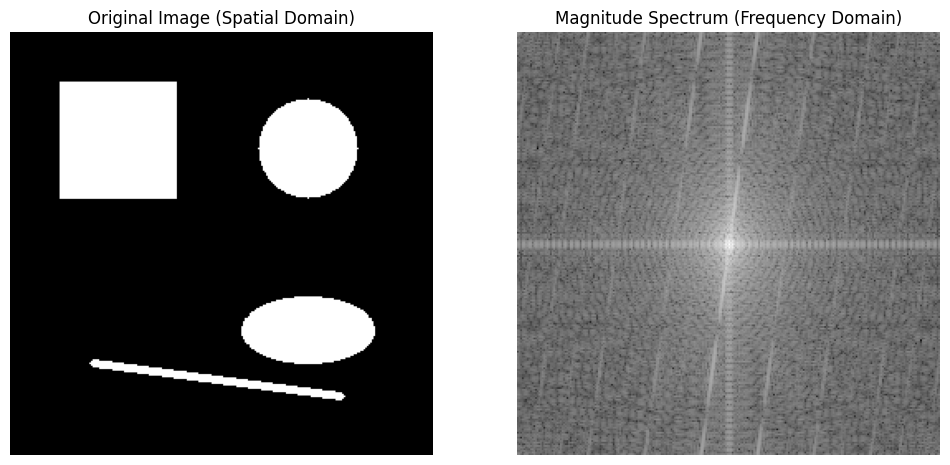

In [5]:
# Fourier Transform (2D)
f = np.fft.fft2(image)  # 2D Fourier transform of the image
fshift = np.fft.fftshift(f)  # Shift zero frequency to center

# Magnitude Spectrum
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)  # To avoid the error log(0) add +1

# Show the image and spectrum
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image (Spatial Domain)")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Magnitude Spectrum (Frequency Domain)")
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.show()

**Explanation:** The Fourier Transform converts the image from spatial to frequency domain, showing energy distribution among frequencies.

# **Step 3: Create a HIGH PASS FILTER that will eliminate the components in the low frequency region of this image and apply it to the image.**

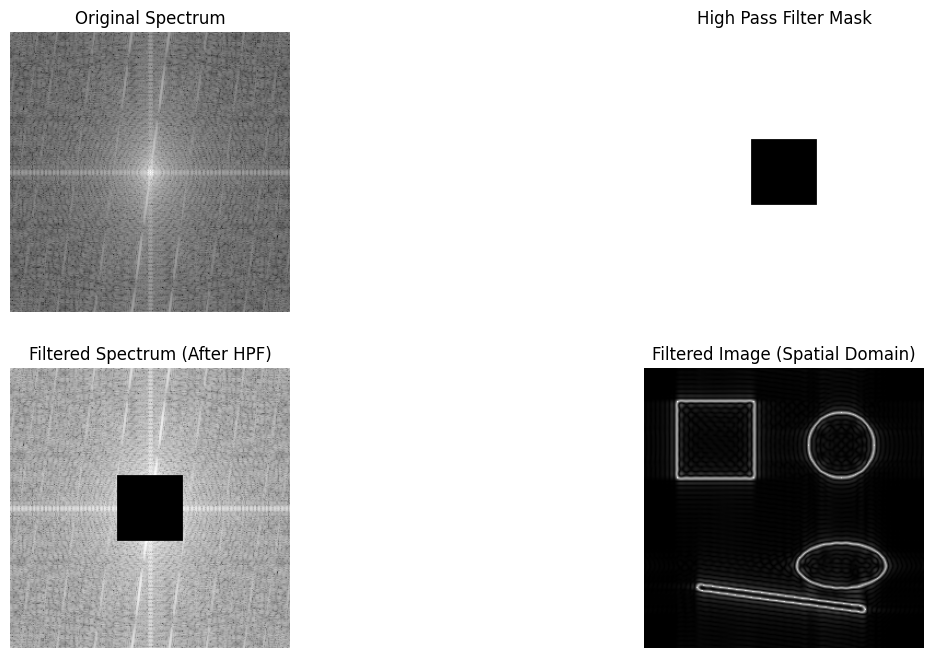

In [6]:
# High Pass Filter (HPF) creation and application

# Dimensions
rows, cols = image.shape
crow, ccol = rows//2 , cols//2  # coordinates of the center

# Create a High Pass Filter mask (0 in the center, 1 on the edges)
hpf_mask = np.ones((rows, cols), np.uint8)
hpf_mask[crow-30:crow+30, ccol-30:ccol+30] = 0  # Zero zone in 60x60 center

# Apply mask in frequency domain
fshift_hpf = fshift * hpf_mask

# Inverse Fourier transform (to get the filtered image)
f_ishift = np.fft.ifftshift(fshift_hpf)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Spectrum (After Filter)
magnitude_spectrum_filtered = 20 * np.log(np.abs(fshift_hpf) + 1)

# Show the results
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.title("Original Spectrum")
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("High Pass Filter Mask")
plt.imshow(hpf_mask*255, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("Filtered Spectrum (After HPF)")
plt.imshow(magnitude_spectrum_filtered, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Filtered Image (Spatial Domain)")
plt.imshow(img_back, cmap='gray')
plt.axis('off')

plt.show()


**Explanation:** After applying the High-Pass Filter (HPF), the resulting image in the spatial domain appears sharper, with most of the low-intensity (smooth) regions suppressed and edges emphasized.
This happens because the HPF removes the low-frequency components, which are responsible for the smooth, gradual variations in the image (such as large uniform areas).
Only the high-frequency components, associated with rapid intensity changes such as object boundaries, are retained.
Thus, the filtered image highlights edges, lines, and fine details while making homogeneous regions almost invisible.




# **Step 4: Create a LOW PASS FILTER that will eliminate the components in the high frequency region of this image and apply it to the image.**

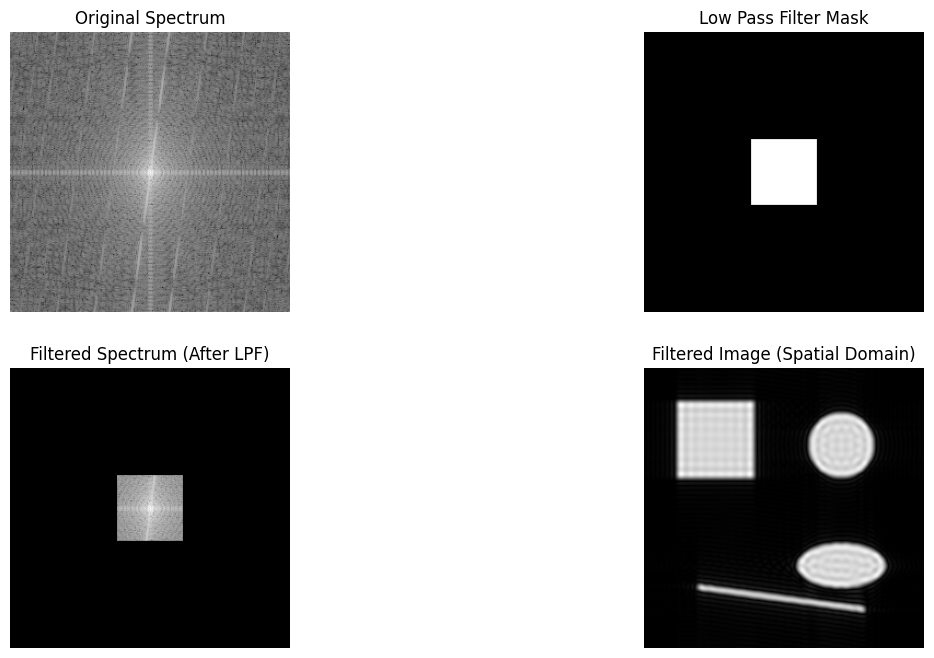

In [7]:
# Low Pass Filter (LPF) creation and application

# Create a Low Pass Filter mask (1 in the center, 0 at the edges)
lpf_mask = np.zeros((rows, cols), np.uint8)
lpf_mask[crow-30:crow+30, ccol-30:ccol+30] = 1  # 60x60 was made in an area 1 in the center

#Apply mask in frequency domain
fshift_lpf = fshift * lpf_mask

# Inverse Fourier transform
f_ishift_lpf = np.fft.ifftshift(fshift_lpf)
img_back_lpf = np.fft.ifft2(f_ishift_lpf)
img_back_lpf = np.abs(img_back_lpf)

# Spectrum (After Filter)
magnitude_spectrum_lpf = 20 * np.log(np.abs(fshift_lpf) + 1)

# Show the results
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.title("Original Spectrum")
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Low Pass Filter Mask")
plt.imshow(lpf_mask*255, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("Filtered Spectrum (After LPF)")
plt.imshow(magnitude_spectrum_lpf, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Filtered Image (Spatial Domain)")
plt.imshow(img_back_lpf, cmap='gray')
plt.axis('off')

plt.show()


**Explanation**: After applying the Low-Pass Filter (LPF), the resulting image in the spatial domain appears blurred, with most of the fine details and sharp edges removed.
This happens because the LPF preserves only the low-frequency components, which correspond to smooth, gradual intensity variations in the image.
High-frequency components, which represent rapid changes such as edges and fine textures, are suppressed.
Thus, the image becomes softer, with a significant loss of detail, giving a "blurred" appearance.

# **Step 5: Add a horizontal cosine wave (a) with a frequency equal to the sum of your school numbers to the image AS NOISE**

Our School Numbers:

220611040 → 2 + 2 + 0 + 6 + 1 + 1 + 0 + 4 + 0 = 16

220611004 → 2 + 2 + 0 + 6 + 1 + 1 + 0 + 0 + 4 = 16

230611011 → 2 + 3 + 0 + 6 + 1 + 1 + 0 + 1 + 1 = 15

16 + 16 + 15 = 47

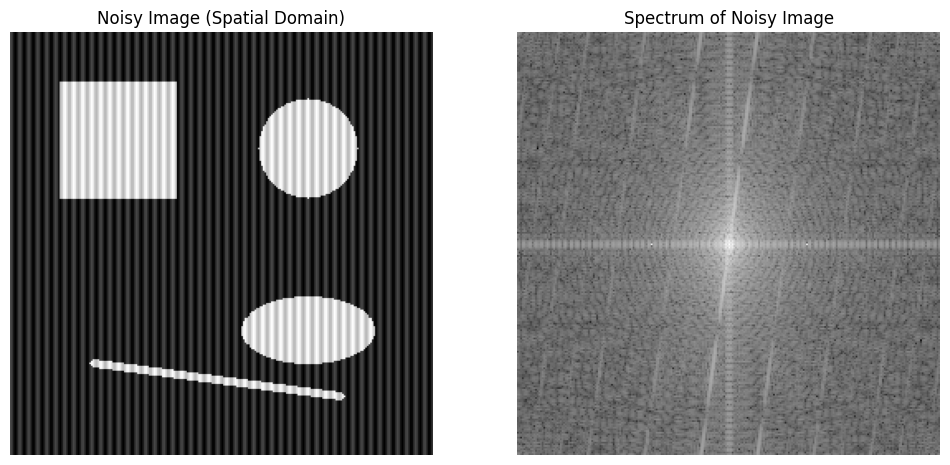

In [8]:
# Add horizontal cosine noise with frequency 47

# Cosine wave generation
x = np.arange(cols)
cos_wave = 50 * np.cos(2 * np.pi * 47 * x / cols)  # Amplitude=50

# Copy cosine wave to each line (horizontal wave)
noise = np.tile(cos_wave, (rows, 1))

# Add noise to the image
noisy_image = image + noise

# Show the result
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Noisy Image (Spatial Domain)")
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

# Extract the spectrum of the noisy image
f_noisy = np.fft.fft2(noisy_image)
fshift_noisy = np.fft.fftshift(f_noisy)
magnitude_spectrum_noisy = 20 * np.log(np.abs(fshift_noisy) + 1)

plt.subplot(1,2,2)
plt.title("Spectrum of Noisy Image")
plt.imshow(magnitude_spectrum_noisy, cmap='gray')
plt.axis('off')

plt.show()

**Explanation:** A horizontal cosine wave of frequency 47 is added to simulate periodic noise. In the spectrum, distinct peaks appear at ±47 frequencies.

# **Step 6: View the obtained noisy image and its spectrum. At which frequency points did PEAK VALUES occur in the spectrum? Why?**

In the spectrum of the noisy image, two distinct peaks appeared along the horizontal axis at ±47 frequency units from the center. This is because a cosine wave consists of two conjugate delta functions at positive and negative frequencies, creating symmetrical peaks in the frequency domain.

# **Step 7: Eliminate the noise using a band-stop filter to remove these peak values. How successfully was the noise eliminated after filtering? Comment**

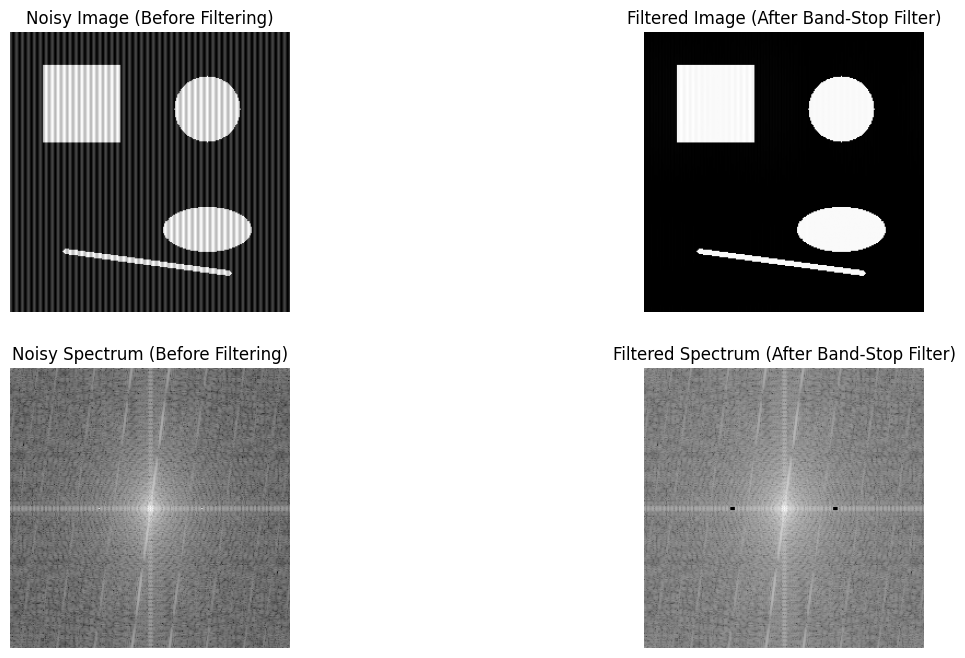

In [9]:
# Band-Stop Filter application

# Create Band-Stop Filter mask
band_stop_mask = np.ones((rows, cols), np.uint8)

# Center coordinates
center_row, center_col = rows // 2, cols // 2

# Make the frequencies around ±47 on the horizontal axis 0
band = 2  # Bandwidth

# Turn off positive frequency
band_stop_mask[center_row-1:center_row+2, center_col+47-band:center_col+47+band] = 0
# Turn off negative frequency
band_stop_mask[center_row-1:center_row+2, center_col-47-band:center_col-47+band] = 0

# Apply mask to noisy spectrum
fshift_filtered = fshift_noisy * band_stop_mask

# Perform inverse Fourier transform
f_ishift_filtered = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift_filtered)
img_filtered = np.abs(img_filtered)

# Calculate new spectrum
magnitude_spectrum_filtered_noise = 20 * np.log(np.abs(fshift_filtered) + 1)

# Show the results
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.title("Noisy Image (Before Filtering)")
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Filtered Image (After Band-Stop Filter)")
plt.imshow(img_filtered, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("Noisy Spectrum (Before Filtering)")
plt.imshow(magnitude_spectrum_noisy, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Filtered Spectrum (After Band-Stop Filter)")
plt.imshow(magnitude_spectrum_filtered_noise, cmap='gray')
plt.axis('off')

plt.show()


After applying the band-stop filter, the two prominent peaks at ±47 frequencies in the spectrum were effectively suppressed.
In the spatial domain, the periodic horizontal stripes introduced by the cosine noise were significantly reduced.
The filtered image closely resembles the original clean synthetic image, showing clear geometric shapes without visible noise artifacts.
Although some very slight residual traces of the noise might still be observable upon very close inspection, overall the filtering was highly successful.

- The frequency spectrum after filtering confirms the effectiveness of the band-stop filter:

- The strong noise peaks are almost entirely removed.

- The background frequencies remain largely intact.

# **References:**

1. Gonzalez, R. C., & Woods, R. E., Digital Image Processing, Pearson, 2018.

2. OpenCV Documentation, https://docs.opencv.org/

3. NumPy Documentation, https://numpy.org/doc/

4. Matplotlib Documentation, https://matplotlib.org/

